# FASE 3 — Entrenamiento

Entrenamos `DermaCNN` con:
- `CrossEntropyLoss` ponderada por clase (desbalance)
- Optimizador `AdamW` + scheduler `CosineAnnealingLR`
- Early stopping para evitar sobreajuste
- Checkpointing del mejor modelo (por F1-Macro en validación)
- Curvas de pérdida y métricas en tiempo real

## 1. Imports y configuración

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time, os
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

# Módulos de fases anteriores
from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## 2. Hiperparámetros

In [2]:
# ── Hiperparámetros ──────────────────────────────────────
CONFIG = {
    'batch_size'    : 64,
    'num_epochs'    : 80,
    'lr'            : 1e-3,      # CAMBIO: más alto (antes 3e-4) para salir del plateau
    'weight_decay'  : 1e-5,      # CAMBIO: mucho menor (antes 1e-4) — menos regularización
    'dropout'       : 0.25,      # CAMBIO: menor (antes 0.4) — red pequeña, no necesita tanto
    'patience'      : 15,        # CAMBIO: más paciencia (antes 12)
    'min_delta'     : 1e-4,
    'checkpoint'    : 'best_model_v3.pth',
    'num_workers'   : 0,
}


for k, v in CONFIG.items():
    print(f'  {k:<16}: {v}')

  batch_size      : 64
  num_epochs      : 80
  lr              : 0.001
  weight_decay    : 1e-05
  dropout         : 0.25
  patience        : 15
  min_delta       : 0.0001
  checkpoint      : best_model_v3.pth
  num_workers     : 0


## 3. DataLoaders, Modelo, Loss, Optimizador

In [3]:
from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN
import torch
import torch.nn as nn

# ── DataLoaders ──────────────────────────────────────────────
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers']
)

# ── Modelo ───────────────────────────────────────────────────
model = DermaCNN(num_classes=NUM_CLASSES, dropout=CONFIG['dropout']).to(DEVICE)

# ── Loss v3 ──────────────────────────────────────────────────
# label_smoothing=0.05 (antes 0.1) — los pesos ya están más balanceados,
# no necesitamos tanto smoothing
class_weights_tensor = torch.FloatTensor(CLASS_WEIGHTS).to(DEVICE)
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.05
)

# ── Optimizador y scheduler: igual que v2 ────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['num_epochs'],
    pct_start=0.2,
    anneal_strategy='cos'
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device             : {DEVICE}')
print(f'Parámetros         : {total_params:,}')
print(f'Checkpoint destino : {CONFIG["checkpoint"]}')
print()
print('Cambios v3 vs v2:')
print('  CLASS_WEIGHTS  → calibrados por F1 obtenido (inversamente proporcional)')
print('  label_smoothing→ 0.05 (antes 0.1)')
print()
print('Lo que NO cambia: lr, dropout, weight_decay, scheduler, augmentation')
print()
print('✅ Listo — corre el loop de entrenamiento (celda 6)')
print()
print('Qué esperar:')
print('  Nevi (clase 5) bajará de precision=0.96 a ~0.80 pero recall subirá')
print('  F1 de clases minoritarias debería subir a 0.45-0.60')
print('  F1-Macro objetivo: >0.65, Accuracy: >0.69')

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Device             : cuda
Parámetros         : 495,032
Checkpoint destino : best_model_v3.pth

Cambios v3 vs v2:
  CLASS_WEIGHTS  → calibrados por F1 obtenido (inversamente proporcional)
  label_smoothing→ 0.05 (antes 0.1)

Lo que NO cambia: lr, dropout, weight_decay, scheduler, augmentation

✅ Listo — corre el loop de entrenamiento (celda 6)

Qué esperar:
  Nevi (clase 5) bajará de precision=0.96 a ~0.80 pero recall subirá
  F1 de clases minoritarias debería subir a 0.45-0.60
  F1-Macro objetivo: >0.65, Accuracy: >0.69


## 4. Funciones de evaluación

In [4]:
def evaluate(model, loader, criterion, device):
    """
    Evalúa el modelo en un dataloader.
    Retorna: loss, accuracy, f1_macro, auc_macro, all_preds, all_labels, all_probs
    """
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []   # probabilidades para AUC

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs


print('✅ Función evaluate() definida')

✅ Función evaluate() definida


## 5. Early Stopping

In [5]:
class EarlyStopping:
    """
    Detiene el entrenamiento si la métrica de validación
    no mejora por `patience` épocas consecutivas.
    Guarda el mejor modelo automáticamente.
    """
    def __init__(self, patience=12, min_delta=1e-4, path='best_model.pth', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self._save(model, score)
            self.best_score = score
            self.counter    = 0

    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        if self.verbose:
            print(f'     ✅ Checkpoint guardado (F1={score:.4f})')


print('✅ EarlyStopping definido')

✅ EarlyStopping definido


## 6. Loop de Entrenamiento

In [6]:
# ── Historial de métricas ────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'train_f1'  : [], 'val_f1'  : [],
    'train_auc' : [], 'val_auc' : [],
    'lr'        : [],
}

early_stopping = EarlyStopping(
    patience=CONFIG['patience'],
    min_delta=CONFIG['min_delta'],
    path=CONFIG['checkpoint']
)

print('Iniciando entrenamiento...')
print('='*70)
start_time = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):

    # ── TRAIN ────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_preds, train_labels_ep = [], []

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{CONFIG["num_epochs"]}',
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — evita explosión de gradientes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    scheduler.step()

    # Métricas de train
    t_loss = train_loss / len(train_loader.dataset)
    t_acc  = accuracy_score(train_labels_ep, train_preds)
    t_f1   = f1_score(train_labels_ep, train_preds, average='macro', zero_division=0)

    # ── VALIDACIÓN ───────────────────────────────────────
    v_loss, v_acc, v_f1, v_auc, _, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    current_lr = optimizer.param_groups[0]['lr']

    # Guardar historial
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['train_f1'].append(t_f1)
    history['val_f1'].append(v_f1)
    history['val_auc'].append(v_auc)
    history['lr'].append(current_lr)

    # Print resumen de época
    elapsed = (time.time() - start_time) / 60
    print(
        f'Ep {epoch:02d} | '
        f'TLoss={t_loss:.4f} Tacc={t_acc:.3f} TF1={t_f1:.3f} | '
        f'VLoss={v_loss:.4f} Vacc={v_acc:.3f} VF1={v_f1:.3f} VAUC={v_auc:.3f} | '
        f'LR={current_lr:.2e} | {elapsed:.1f}min'
    )

    # Early stopping (monitor: F1-Macro en validación)
    early_stopping(v_f1, model)
    if early_stopping.stop:
        print(f'\n⛔ Early stopping en época {epoch}')
        break

total_time = (time.time() - start_time) / 60
print('='*70)
print(f'Entrenamiento finalizado en {total_time:.1f} min')
print(f'Mejor F1-Macro en validación: {early_stopping.best_score:.4f}')

Iniciando entrenamiento...


Ep 01 | TLoss=1.8215 Tacc=0.386 TF1=0.167 | VLoss=1.6704 Vacc=0.491 VF1=0.179 VAUC=0.772 | LR=4.00e-05 | 0.7min
     ✅ Checkpoint guardado (F1=0.1792)


Ep 02 | TLoss=1.6791 Tacc=0.467 TF1=0.220 | VLoss=1.5935 Vacc=0.498 VF1=0.200 VAUC=0.805 | LR=4.00e-05 | 1.3min
     ✅ Checkpoint guardado (F1=0.1999)


Ep 03 | TLoss=1.6376 Tacc=0.482 TF1=0.256 | VLoss=1.5352 Vacc=0.546 VF1=0.264 VAUC=0.812 | LR=4.00e-05 | 1.9min
     ✅ Checkpoint guardado (F1=0.2637)


Ep 04 | TLoss=1.5871 Tacc=0.511 TF1=0.283 | VLoss=1.5137 Vacc=0.560 VF1=0.277 VAUC=0.822 | LR=4.00e-05 | 2.4min
     ✅ Checkpoint guardado (F1=0.2767)


...

Ep 76 | TLoss=1.0178 Tacc=0.729 TF1=0.543 | VLoss=1.0337 Vacc=0.715 VF1=0.431 VAUC=0.911 | LR=4.45e-05 | 44.6min
     EarlyStopping: 2/15


Ep 77 | TLoss=1.0040 Tacc=0.731 TF1=0.552 | VLoss=1.0410 Vacc=0.706 VF1=0.482 VAUC=0.910 | LR=4.46e-05 | 45.2min
     EarlyStopping: 3/15


Ep 78 | TLoss=1.0183 Tacc=0.726 TF1=0.548 | VLoss=1.0339 Vacc=0.714 VF1=0.491 VAUC=0.918 | LR=4.47e-05 | 45.8min
     ✅ Checkpoint guardado (F1=0.4913)


Ep 79 | TLoss=0.9981 Tacc=0.731 TF1=0.555 | VLoss=1.0279 Vacc=0.708 VF1=0.471 VAUC=0.910 | LR=4.49e-05 | 46.3min
     EarlyStopping: 1/15


Ep 80 | TLoss=0.9969 Tacc=0.736 TF1=0.541 | VLoss=1.0197 Vacc=0.740 VF1=0.506 VAUC=0.916 | LR=4.50e-05 | 46.9min
     ✅ Checkpoint guardado (F1=0.5056)
Entrenamiento finalizado en 46.9 min
Mejor F1-Macro en validación: 0.5056


## 7. Curvas de Entrenamiento

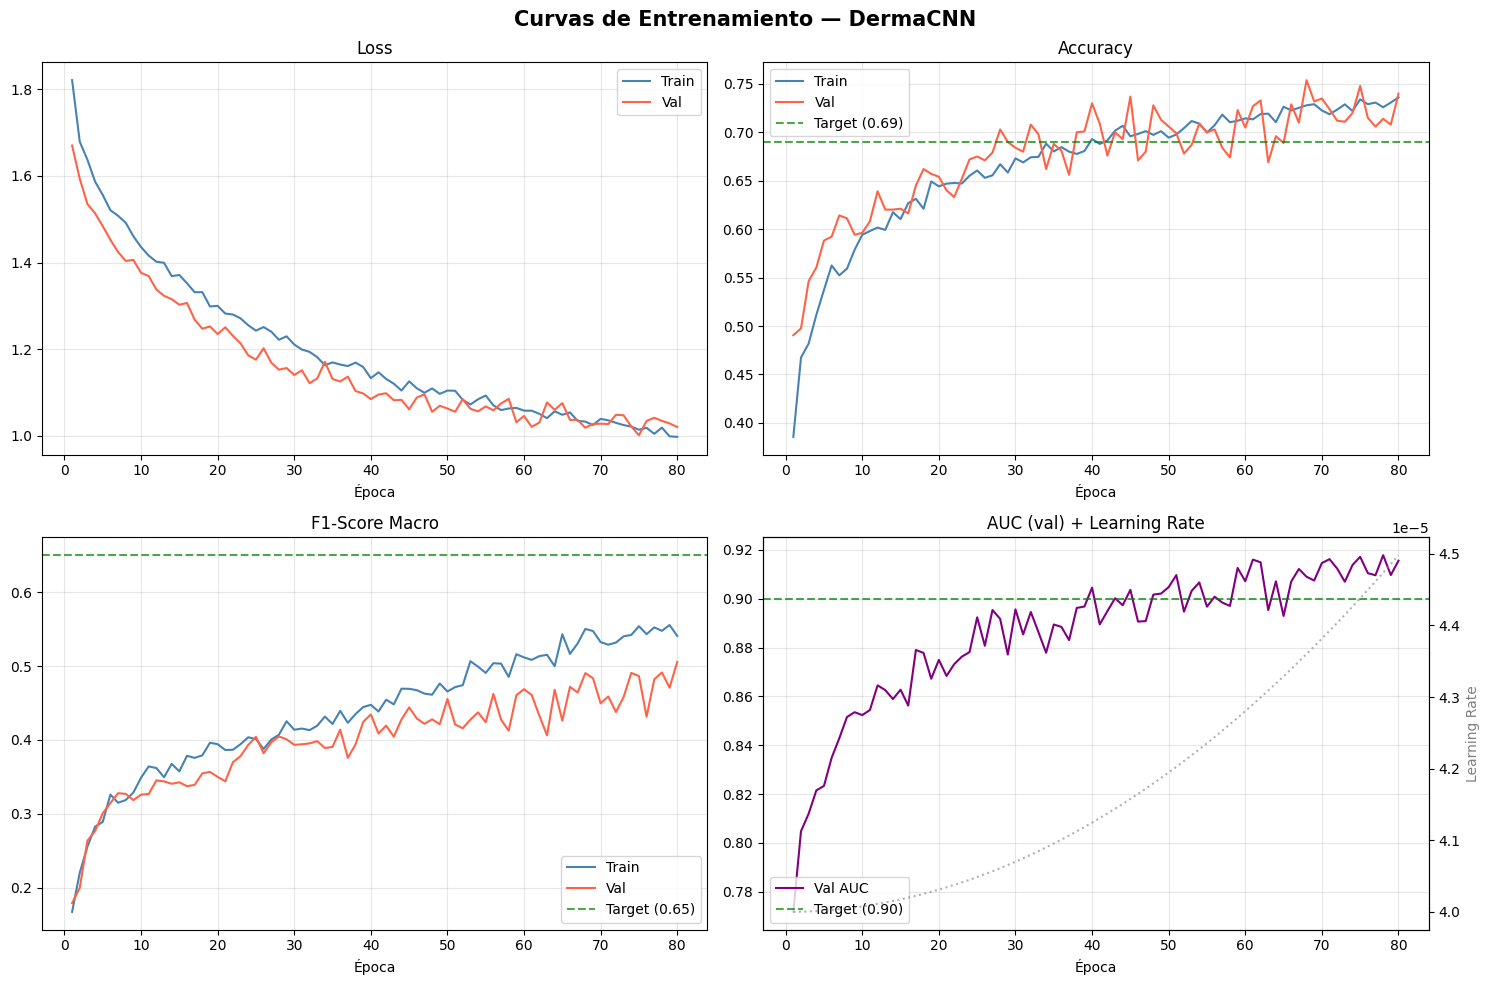

✅ Guardado: curvas_entrenamiento.png


In [7]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Entrenamiento — DermaCNN', fontsize=15, fontweight='bold')

# Loss
ax = axes[0][0]
ax.plot(ep_range, history['train_loss'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_loss'],   label='Val',   color='tomato')
ax.set_title('Loss')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[0][1]
ax.plot(ep_range, history['train_acc'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_acc'],   label='Val',   color='tomato')
ax.axhline(0.69, color='green', linestyle='--', alpha=0.7, label='Target (0.69)')
ax.set_title('Accuracy')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# F1-Macro
ax = axes[1][0]
ax.plot(ep_range, history['train_f1'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_f1'],   label='Val',   color='tomato')
ax.axhline(0.65, color='green', linestyle='--', alpha=0.7, label='Target (0.65)')
ax.set_title('F1-Score Macro')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# AUC + LR
ax = axes[1][1]
ax.plot(ep_range, history['val_auc'], label='Val AUC', color='purple')
ax.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='Target (0.90)')
ax2 = ax.twinx()
ax2.plot(ep_range, history['lr'], color='gray', linestyle=':', alpha=0.6, label='LR')
ax2.set_ylabel('Learning Rate', color='gray')
ax.set_title('AUC (val) + Learning Rate')
ax.set_xlabel('Época')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: curvas_entrenamiento.png')

## 8. Evaluación Final en Test Set

In [8]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(CONFIG['checkpoint'], map_location=DEVICE))
print(f'Modelo cargado desde: {CONFIG["checkpoint"]}')

# Evaluar en Test Set
test_loss, test_acc, test_f1, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print()
print('='*50)
print('  RESULTADOS FINALES — TEST SET')
print('='*50)

TARGETS = {'Accuracy': 0.69, 'AUC': 0.90, 'F1-Macro': 0.65}
results  = {'Accuracy': test_acc, 'AUC': test_auc, 'F1-Macro': test_f1}

for metric, value in results.items():
    target = TARGETS[metric]
    status = 'ok -' if value >= target else 'X'
    print(f'  {status} {metric:<12}: {value:.4f}  (target ≥ {target})')

print('='*50)
all_pass = all(results[m] >= TARGETS[m] for m in TARGETS)
print(f'  {"APROBADO" if all_pass else "AÚN NO CUMPLE"}')
print('='*50)

C:\Users\isape\AppData\Local\Temp\ipykernel_12328\3200187190.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG['checkpoint'], map_l

Modelo cargado desde: best_model_v3.pth

  RESULTADOS FINALES — TEST SET
  ok - Accuracy    : 0.7202  (target ≥ 0.69)
  ok - AUC         : 0.9191  (target ≥ 0.9)
  X F1-Macro    : 0.4739  (target ≥ 0.65)
  AÚN NO CUMPLE


## 9. Matriz de Confusión

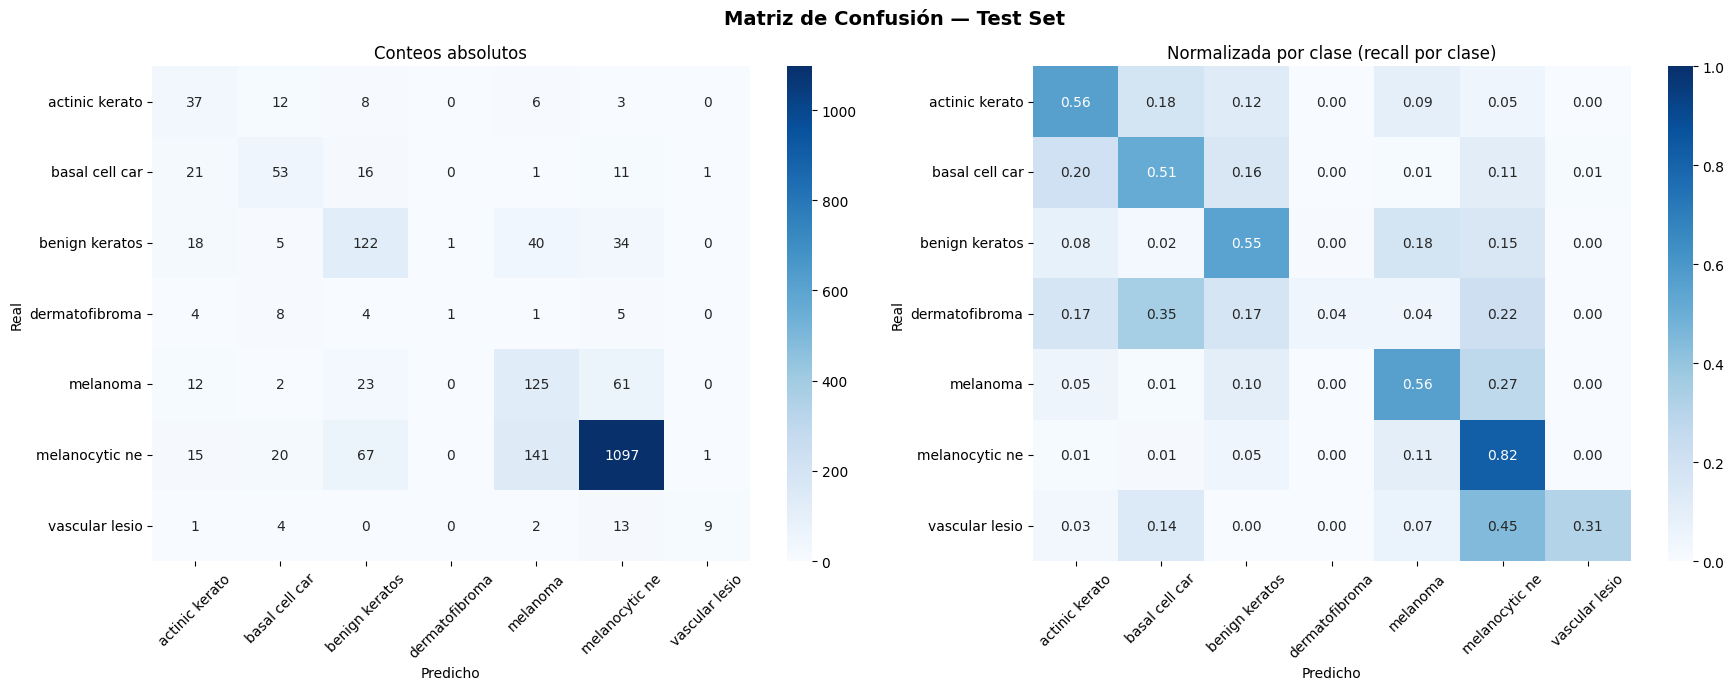

✅ Guardado: confusion_matrix.png

Reporte por clase:
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.34      0.56      0.43        66
                           basal cell carcinoma       0.51      0.51      0.51       103
                  benign keratosis-like lesions       0.51      0.55      0.53       220
                                 dermatofibroma       0.50      0.04      0.08        23
                                       melanoma       0.40      0.56      0.46       223
                               melanocytic nevi       0.90      0.82      0.86      1341
                               vascular lesions       0.82      0.31      0.45        29

                                       accuracy                           0.72      2005
                                      macro avg       0.57      0.48      0.47      2005
                                   weighted avg       0

In [9]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

short_names = [n[:14] for n in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title('Conteos absolutos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalizada por clase (recall por clase)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: confusion_matrix.png')

# Métricas por clase
from sklearn.metrics import classification_report
print('\nReporte por clase:')
print(classification_report(test_labels, test_preds,
      target_names=CLASS_NAMES, zero_division=0))

## 11. Guardar artefactos para Fase 4

In [10]:
import pickle

# Guardar resultados del test para usar en Fase 4 (Grad-CAM)
artefactos = {
    'test_preds' : test_preds,
    'test_labels': test_labels,
    'test_probs' : test_probs,
    'history'    : history,
    'test_acc'   : test_acc,
    'test_f1'    : test_f1,
    'test_auc'   : test_auc,
}

with open('test_results.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Archivos listos para Fase 4:')
print('  best_model.pth    — pesos del mejor modelo')
print('  test_results.pkl  — métricas y predicciones del test set')
print('  curvas_entrenamiento.png — para el reporte IEEE')
print('  confusion_matrix.png    — para el reporte IEEE')
print()
print('✅ Fase 3 completa — listo para Fase 4: Grad-CAM')

Archivos listos para Fase 4:
  best_model.pth    — pesos del mejor modelo
  test_results.pkl  — métricas y predicciones del test set
  curvas_entrenamiento.png — para el reporte IEEE
  confusion_matrix.png    — para el reporte IEEE

✅ Fase 3 completa — listo para Fase 4: Grad-CAM


## ✅ Resumen Fase 3

| Decisión | Justificación |
|----------|---------------|
| `AdamW` | Mejor regularización que Adam estándar (weight decay separado) |
| `CosineAnnealingLR` | Evita mínimos locales — baja LR suavemente |
| `CrossEntropyLoss(weight=...)` | Segunda línea de defensa contra desbalance |
| Gradient clipping (norm=1.0) | Evita explosión de gradientes en las fusiones no lineales |
| Early stopping en F1-Macro | Métrica más representativa para datasets desbalanceados |
| Checkpoint del mejor modelo | Evita sobreajuste al final del entrenamiento |

**Siguiente paso → Fase 4: Evaluación + Grad-CAM (XAI)**